In [139]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

In [140]:
mat_contents = scipy.io.loadmat('../../DATA/allFaces.mat')

- face: 32256 * 2410 第一个维度按照列排列(这就是为什么后面需要转置) 第二个维度 = $\sum nfaces$ 
- n: 192 长度
- m: 168 宽度
- nfaces:1 * 38 每个人照片的数量

code1.6: Plot image for each person in the Yale database

In [141]:
faces = mat_contents['faces']
m = int(mat_contents['m'])
n = int(mat_contents['n'])
nfaces = np.array(mat_contents['nfaces'])

/var/folders/t9/n3zhf08n4cv_ns10b375thxr0000gn/T/ipykernel_1419/2652126350.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(mat_contents['m'])
/var/folders/t9/n3zhf08n4cv_ns10b375thxr0000gn/T/ipykernel_1419/2652126350.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(mat_contents['n'])


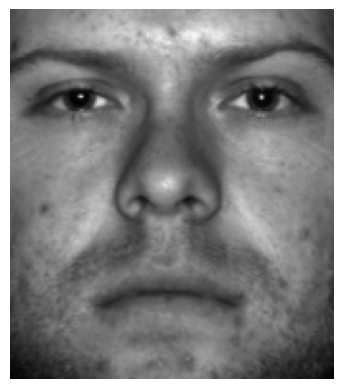

In [142]:
# 先实现一个最小的算例，为后面打基础
p1 = np.reshape((mat_contents['faces'])[:,0],(m,n)).T
img1 = plt.imshow(p1)
img1.set_cmap('gray')
plt.axis('off')
plt.show()

In [143]:
all_Persons = np.zeros((6 * n,6 * m))
count = 0

In [144]:
for j in range(6): # 行
    for k in range(6): # 列
        # 先把行填满，再接着往下
        all_Persons[j*n:(j+1)*n,k*m:(k+1)*m] = np.reshape(faces[:,np.sum(nfaces[0,0:count])],(m,n)).T
        count += 1

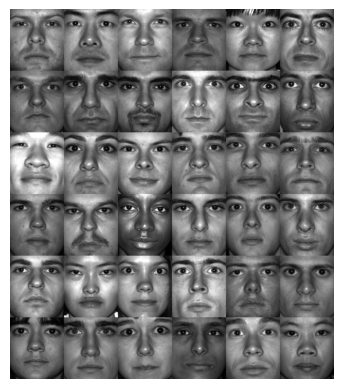

In [145]:
img = plt.imshow(all_Persons)
img.set_cmap('gray')
plt.axis('off')
plt.show()

code1.7: Compute eigenfaces on mean-substracted data

In [146]:
# 不止包括第一张脸，所有的都要包含进去
trainingFaces = faces[:,:np.sum(nfaces[0,0:36])]
avgFace = np.mean(trainingFaces,axis=1).reshape(-1,1)

In [147]:
X = trainingFaces-avgFace

In [148]:
U, Sigma, V = np.linalg.svd(X,full_matrices=False)

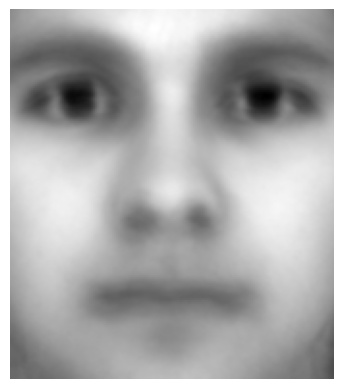

In [149]:
img_avg = plt.imshow(np.reshape(avgFace,(m,n)).T,cmap='gray')
plt.axis('off')
plt.show()

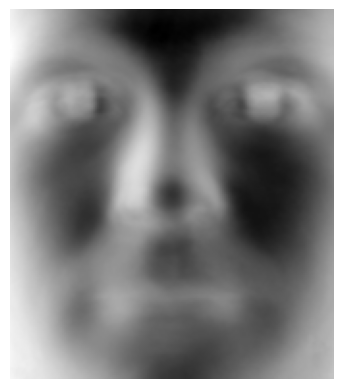

In [150]:
img_u1 = plt.imshow(np.reshape(U[:,0],(m,n)).T,cmap='gray')
plt.axis('off')
plt.show()

code1.8: Approximate test image omitted from training data

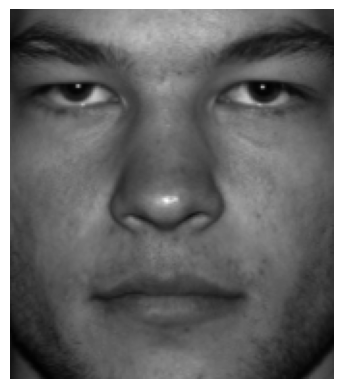

In [151]:
testFace = faces[:,np.sum(nfaces[0,0:36])].reshape(-1,1)
img = plt.imshow(np.reshape(testFace,(m,n)).T)
img.set_cmap('gray')
plt.axis('off')
plt.show()

In [152]:
testFaceMS = testFace - avgFace

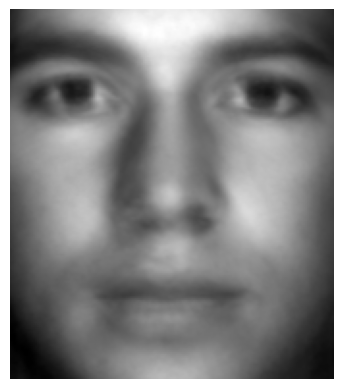

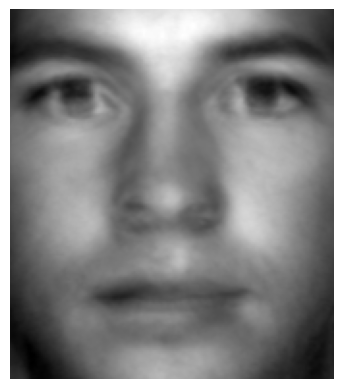

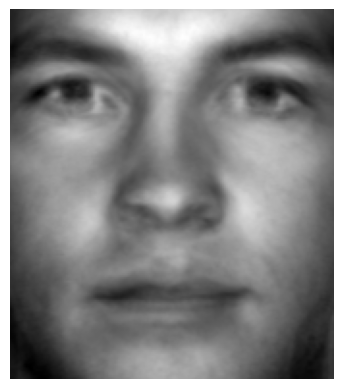

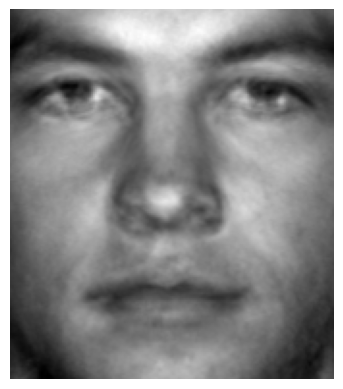

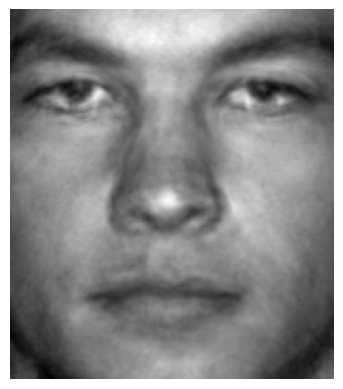

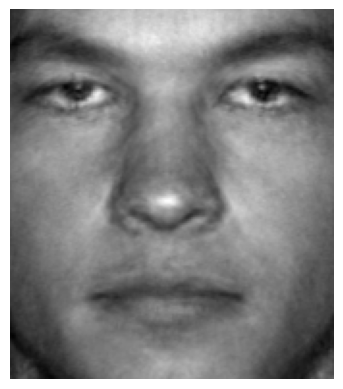

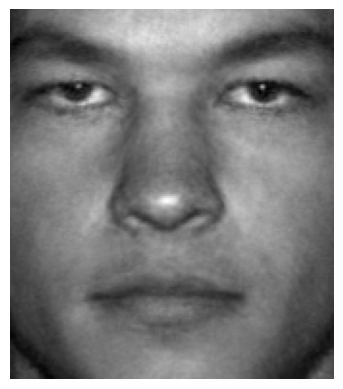

In [153]:
r_list = [25,50,100,200,400,800,1600]
for r in r_list:
    reconFace = avgFace + U[:,:r] @ U[:,:r].T @ testFaceMS
    img = plt.imshow(np.reshape(reconFace,(m,n)).T)
    img.set_cmap('gray')
    plt.axis('off')
    plt.show()

code1.9: Project images for two specific people onto the 5th and 6th  eigenfaces to illustrate the potential for automated classification.

In [154]:
P1num = 2
P2num = 7

In [155]:
P1 = faces[:,np.sum(nfaces[0,0:P1num-1]):np.sum(nfaces[0,:P1num])]
P2 = faces[:,np.sum(nfaces[0,0:P2num-1]):np.sum(nfaces[0,:P2num])]

In [156]:
P1 = P1 - avgFace
P2 = P2 - avgFace

In [157]:
PCAmodes = [5, 6]
PCAcoordsP1 = U[:,PCAmodes - np.ones_like(PCAmodes)].T @ P1
PCAcoordsP2 = U[:,PCAmodes - np.ones_like(PCAmodes)].T @ P2


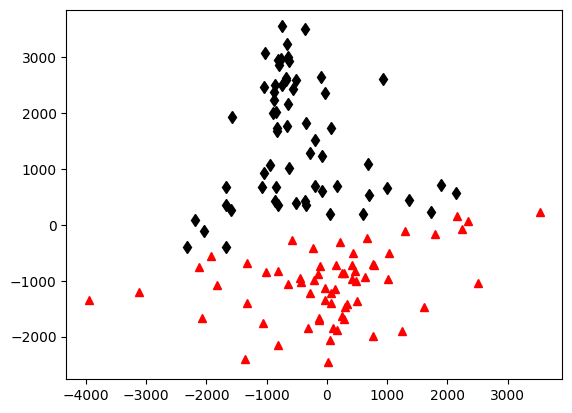

In [158]:
plt.plot(PCAcoordsP1[0,:],PCAcoordsP1[1,:],'d',color='black')
plt.plot(PCAcoordsP2[0,:],PCAcoordsP2[1,:],'^',color='red')
plt.show()
